# Produce Spoilage Risk & Shelf Life Prediction
This notebook builds two models from cold-storage / transport sensor data:
1. **Classification model** — predicts `spoilage_risk_class` (Low / Medium / High)
2. **Regression model** — predicts `remaining_shelf_life_hours`

Note: the raw dataset actually has 4 risk labels (Low/Medium/High/Critical), but High and Critical get merged into one `High` class during cleaning (Step 4d) — they were the most confused pair of classes and merging them gives a cleaner, more balanced 3-class problem.

We'll follow the same step-by-step flow used before: load data, inspect it, clean it, explore it, encode it, engineer a feature, run a statistical test, split/scale it, train and compare models, tune the best one, and finally save everything with joblib so it can be reused inside a Streamlit app.

## Step 1: Import Libraries

In [1]:
# basic libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


## Step 2: Import the Dataset

In [2]:
# loading the dataset
df = pd.read_csv("produce_spoilage_raw_dataset.csv")

# quick look at the first few rows
df.head()


,produce_type,region,storage_temperature_C,humidity_pct,ambient_temperature_level,storage_duration_bucket,transport_duration_bucket,co2_level_bucket,ethylene_level_bucket,vibration_level,light_exposure_level,door_open_frequency,power_outage_bucket,initial_quality_grade,spoilage_risk_class,remaining_shelf_life_hours
0,Spinach,South,3.3,100.0,Cool (<10°C),Less than 1 day,More than 24 hrs,High,Moderate,Mild,Low,3-5 times,Less than 30 min,Excellent,High,146.6
1,Banana,South,10.8,76.9,Hot (>30°C),More than 7 days,6-12 hrs,Elevated,Moderate,Severe,Dark,6-10 times,No Outage,Excellent,High,233.4
2,Spinach,Central,-0.2,94.5,Cool (<10°C),More than 7 days,Less than 6 hrs,Normal,Low,Minimal,Low,3-5 times,Less than 30 min,Excellent,Medium,209.8
3,Tomato,South,NaN,94.6,Warm (20-30°C),3-7 days,Less than 6 hrs,Elevated,High,Minimal,Dark,6-10 times,No Outage,Fair,Medium,222.9
4,Carrot,North,0.4,85.6,Cool (<10°C),More than 7 days,6-12 hrs,Elevated,Low,Moderate,Low,3-5 times,No Outage,Good,Medium,1794.2


## Step 3: Data Inspection

In [3]:
# first 5 rows
df.head()

,produce_type,region,storage_temperature_C,humidity_pct,ambient_temperature_level,storage_duration_bucket,transport_duration_bucket,co2_level_bucket,ethylene_level_bucket,vibration_level,light_exposure_level,door_open_frequency,power_outage_bucket,initial_quality_grade,spoilage_risk_class,remaining_shelf_life_hours
0,Spinach,South,3.3,100.0,Cool (<10°C),Less than 1 day,More than 24 hrs,High,Moderate,Mild,Low,3-5 times,Less than 30 min,Excellent,High,146.6
1,Banana,South,10.8,76.9,Hot (>30°C),More than 7 days,6-12 hrs,Elevated,Moderate,Severe,Dark,6-10 times,No Outage,Excellent,High,233.4
2,Spinach,Central,-0.2,94.5,Cool (<10°C),More than 7 days,Less than 6 hrs,Normal,Low,Minimal,Low,3-5 times,Less than 30 min,Excellent,Medium,209.8
3,Tomato,South,NaN,94.6,Warm (20-30°C),3-7 days,Less than 6 hrs,Elevated,High,Minimal,Dark,6-10 times,No Outage,Fair,Medium,222.9
4,Carrot,North,0.4,85.6,Cool (<10°C),More than 7 days,6-12 hrs,Elevated,Low,Moderate,Low,3-5 times,No Outage,Good,Medium,1794.2


In [4]:
# last 5 rows
df.tail()

,produce_type,region,storage_temperature_C,humidity_pct,ambient_temperature_level,storage_duration_bucket,transport_duration_bucket,co2_level_bucket,ethylene_level_bucket,vibration_level,light_exposure_level,door_open_frequency,power_outage_bucket,initial_quality_grade,spoilage_risk_class,remaining_shelf_life_hours
10395,Potato,Central,8.6,87.4,Cool (<10°C),More than 7 days,Less than 6 hrs,Normal,Low,Mild,Dark,3-5 times,No Outage,Excellent,Medium,1281.3
10396,Spinach,South,-0.2,95.5,Cool (<10°C),3-7 days,Less than 6 hrs,Elevated,Low,Severe,Low,3-5 times,No Outage,Excellent,Medium,181.6
10397,Lettuce,Central,0.4,100.0,Cool (<10°C),1-3 days,6-12 hrs,Elevated,Moderate,Moderate,Low,3-5 times,No Outage,Excellent,Medium,259.2
10398,Lettuce,West,NaN,91.4,Cool (<10°C),3-7 days,Less than 6 hrs,Elevated,Low,Mild,Low,3-5 times,Less than 30 min,Excellent,Medium,256.0
10399,Mango,West,12.0,70.4,Warm (20-30°C),More than 7 days,Less than 6 hrs,Elevated,Moderate,Minimal,Low,3-5 times,No Outage,Excellent,Medium,398.9


In [5]:
# shape -> (rows, columns)
df.shape

(10400, 16)

In [6]:
# size -> total number of cells (rows x columns)
df.size

166400

In [7]:
# info -> column names, data types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   produce_type                10262 non-null  object 
 1   region                      10259 non-null  object 
 2   storage_temperature_C       10233 non-null  float64
 3   humidity_pct                10239 non-null  float64
 4   ambient_temperature_level   10247 non-null  object 
 5   storage_duration_bucket     10242 non-null  object 
 6   transport_duration_bucket   10225 non-null  object 
 7   co2_level_bucket            10255 non-null  object 
 8   ethylene_level_bucket       10256 non-null  object 
 9   vibration_level             10260 non-null  object 
 10  light_exposure_level        10254 non-null  object 
 11  door_open_frequency         10242 non-null  object 
 12  power_outage_bucket         10241 non-null  object 
 13  initial_quality_grade       102

In [8]:
# describe -> statistical summary
# most columns are categorical (MCQ-style answers), so let's check both

# numeric columns (the 2 sliders + the 2 targets)
df.describe()


,storage_temperature_C,humidity_pct,remaining_shelf_life_hours
count,10233.000000,10239.000000,10400.000000
mean,5.229034,87.861783,664.895510
std,6.791898,9.789718,556.277199
min,-10.000000,46.600000,65.800000
25%,0.200000,82.200000,226.500000
50%,4.600000,89.200000,297.000000
75%,10.000000,95.600000,1139.350000
max,25.000000,100.000000,2293.100000


In [9]:
# categorical columns summary
df.describe(include="object")


,produce_type,region,ambient_temperature_level,storage_duration_bucket,transport_duration_bucket,co2_level_bucket,ethylene_level_bucket,vibration_level,light_exposure_level,door_open_frequency,power_outage_bucket,initial_quality_grade,spoilage_risk_class
count,10262,10259,10247,10242,10225,10255,10256,10260,10254,10242,10241,10251,10400
unique,10,5,4,4,4,4,4,4,4,4,4,4,4
top,Lettuce,Central,Moderate (10-20°C),More than 7 days,Less than 6 hrs,Elevated,Low,Mild,Low,3-5 times,No Outage,Excellent,Medium
freq,1086,2129,4186,4619,3531,4527,4242,3798,5332,5630,5904,5195,5184


## Step 4: Data Cleaning

### 4a. Missing Values

In [10]:
# check how many missing values each column has
df.isnull().sum()

produce_type                  138
region                        141
storage_temperature_C         167
humidity_pct                  161
ambient_temperature_level     153
storage_duration_bucket       158
transport_duration_bucket     175
co2_level_bucket              145
ethylene_level_bucket         144
vibration_level               140
light_exposure_level          146
door_open_frequency           158
power_outage_bucket           159
initial_quality_grade         149
spoilage_risk_class             0
remaining_shelf_life_hours      0
dtype: int64

In [11]:
print("Total missing values before dropping:", df.isnull().sum().sum())

# these are skipped sensor readings / unanswered form fields, so we simply
# drop rows with any missing value rather than guessing/imputing
df = df.dropna()

print("Shape after dropping missing values:", df.shape)


Total missing values before dropping: 2134
Shape after dropping missing values: (8452, 16)


### 4b. Duplicates

In [12]:
print("Duplicate rows before removing:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Duplicate rows before removing: 255
Shape after removing duplicates: (8197, 16)


In [13]:
# reset index after dropping rows so it's continuous again (0,1,2,3...)
df = df.reset_index(drop=True)
df.head()


,produce_type,region,storage_temperature_C,humidity_pct,ambient_temperature_level,storage_duration_bucket,transport_duration_bucket,co2_level_bucket,ethylene_level_bucket,vibration_level,light_exposure_level,door_open_frequency,power_outage_bucket,initial_quality_grade,spoilage_risk_class,remaining_shelf_life_hours
0,Spinach,South,3.3,100.0,Cool (<10°C),Less than 1 day,More than 24 hrs,High,Moderate,Mild,Low,3-5 times,Less than 30 min,Excellent,High,146.6
1,Banana,South,10.8,76.9,Hot (>30°C),More than 7 days,6-12 hrs,Elevated,Moderate,Severe,Dark,6-10 times,No Outage,Excellent,High,233.4
2,Spinach,Central,-0.2,94.5,Cool (<10°C),More than 7 days,Less than 6 hrs,Normal,Low,Minimal,Low,3-5 times,Less than 30 min,Excellent,Medium,209.8
3,Carrot,North,0.4,85.6,Cool (<10°C),More than 7 days,6-12 hrs,Elevated,Low,Moderate,Low,3-5 times,No Outage,Good,Medium,1794.2
4,Carrot,East,-5.9,100.0,Moderate (10-20°C),More than 7 days,6-12 hrs,Normal,Moderate,Minimal,Dark,3-5 times,No Outage,Good,Critical,1277.8


### 4c. Data Type Check

In [14]:
# confirming every column has the expected data type
df.dtypes


produce_type                   object
region                         object
storage_temperature_C         float64
humidity_pct                  float64
ambient_temperature_level      object
storage_duration_bucket        object
transport_duration_bucket      object
co2_level_bucket               object
ethylene_level_bucket          object
vibration_level                object
light_exposure_level           object
door_open_frequency            object
power_outage_bucket            object
initial_quality_grade          object
spoilage_risk_class            object
remaining_shelf_life_hours    float64
dtype: object

### 4d. Merging Risk Classes (Low / Medium / High / Critical -> Low / Medium / High)
Earlier testing showed that `High` and `Critical` get confused with each other a lot (they sit right next to each other on the same continuous risk scale, so the boundary between them is fuzzy). Merging them into one `High` class removes this confusion and also gives us a more balanced target for the classifier.

In [15]:
print("Before merging:")
print(df["spoilage_risk_class"].value_counts())

# Critical was the most severe risk bucket - we fold it into High since the
# two were the most confused pair (adjacent classes on the same risk scale)
df["spoilage_risk_class"] = df["spoilage_risk_class"].replace("Critical", "High")

print("\nAfter merging Critical into High:")
print(df["spoilage_risk_class"].value_counts())


Before merging:
spoilage_risk_class
Medium      4097
High        2230
Critical    1204
Low          666
Name: count, dtype: int64

After merging Critical into High:
spoilage_risk_class
Medium    4097
High      3434
Low        666
Name: count, dtype: int64


### 4e. Outlier Check (IQR method)
We only run IQR on the 2 truly continuous numeric sensor columns (`storage_temperature_C`, `humidity_pct`) — the rest are already fixed MCQ-style buckets.

In [16]:
# IQR method: anything beyond 1.5 * IQR from Q1/Q3 is treated as an outlier
for col in ["storage_temperature_C", "humidity_pct"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col}: {n_outliers} outliers found (bounds: {lower_bound:.1f} to {upper_bound:.1f})")

    # instead of dropping these rows (and losing data), we cap them at the
    # boundary values - a common beginner-friendly way to handle outliers
    df[col] = df[col].clip(lower_bound, upper_bound)


storage_temperature_C: 6 outliers found (bounds: -14.5 to 24.7)
humidity_pct: 123 outliers found (bounds: 61.7 to 116.1)


## Step 5: Data Analysis (Group By, Pivot Table)

In [17]:
# does spoilage risk differ by produce type?
df.groupby("produce_type")["spoilage_risk_class"].value_counts(normalize=True).round(2)


produce_type  spoilage_risk_class
Apple         Medium                 0.48
              High                   0.46
              Low                    0.06
Banana        High                   0.46
              Medium                 0.46
              Low                    0.08
Carrot        Medium                 0.51
              High                   0.39
              Low                    0.10
Lettuce       Medium                 0.52
              High                   0.40
              Low                    0.08
Mango         High                   0.48
              Medium                 0.46
              Low                    0.06
Onion         Medium                 0.54
              High                   0.35
              Low                    0.11
Peach         High                   0.52
              Medium                 0.43
              Low                    0.05
Potato        Medium                 0.56
              High                   0.33


In [18]:
# does spoilage risk differ by how long it sat in storage?
df.groupby("storage_duration_bucket")["spoilage_risk_class"].value_counts(normalize=True).round(2)


storage_duration_bucket  spoilage_risk_class
1-3 days                 Medium                 0.61
                         High                   0.27
                         Low                    0.12
3-7 days                 Medium                 0.53
                         High                   0.40
                         Low                    0.07
Less than 1 day          Medium                 0.61
                         High                   0.22
                         Low                    0.17
More than 7 days         High                   0.55
                         Medium                 0.41
                         Low                    0.04
Name: proportion, dtype: float64

In [19]:
# pivot table: produce type vs risk class (counts)
pivot1 = df.pivot_table(index="produce_type", columns="spoilage_risk_class",
                         values="humidity_pct", aggfunc="count")
pivot1


spoilage_risk_class,High,Low,Medium
produce_type,,,
Apple,367,49,384
Banana,356,59,351
Carrot,325,79,424
Lettuce,338,68,448
Mango,376,48,363
Onion,282,85,434
Peach,441,38,364
Potato,284,96,479
Spinach,334,82,430


**Observation:** Some produce types (like leafy greens) show a higher share of High/Critical risk than root vegetables, which naturally tolerate longer storage. Storage duration also shows a clear pattern — the longer produce sits in storage, the more it shifts toward Medium/High risk.

## Step 6: Exploratory Data Analysis (EDA)

### 6a. Univariate Analysis

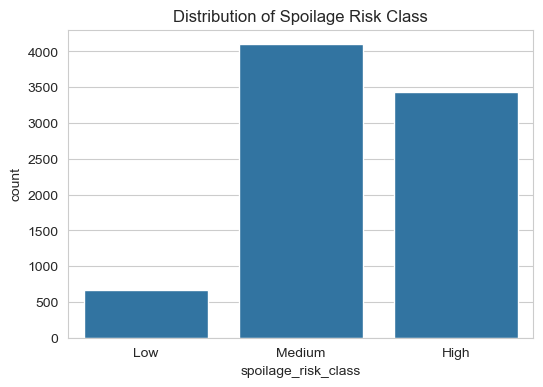

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="spoilage_risk_class", order=["Low","Medium","High"])
plt.title("Distribution of Spoilage Risk Class")
plt.show()


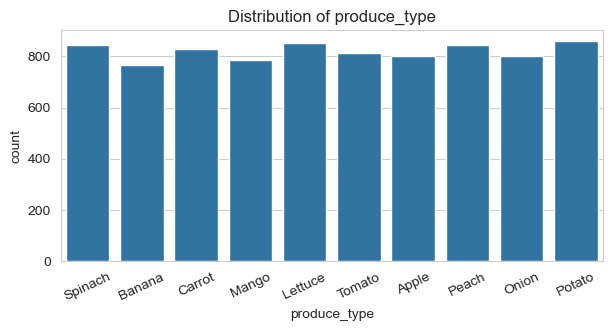

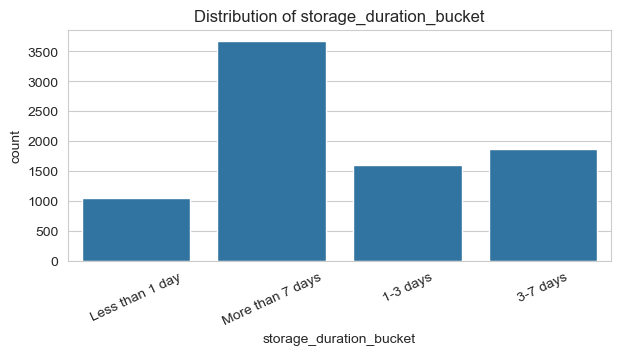

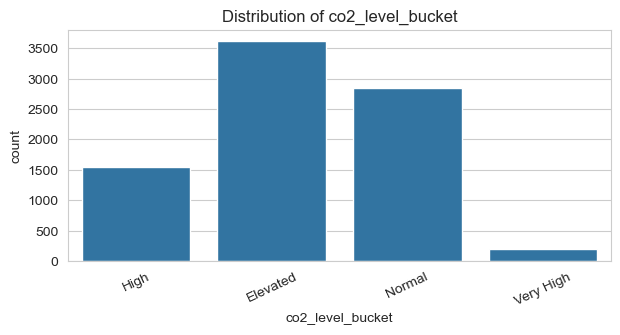

In [21]:
cols_to_check = ["produce_type", "storage_duration_bucket", "co2_level_bucket"]

for col in cols_to_check:
    plt.figure(figsize=(7,3))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=25)
    plt.show()


### 6b. Bivariate Analysis

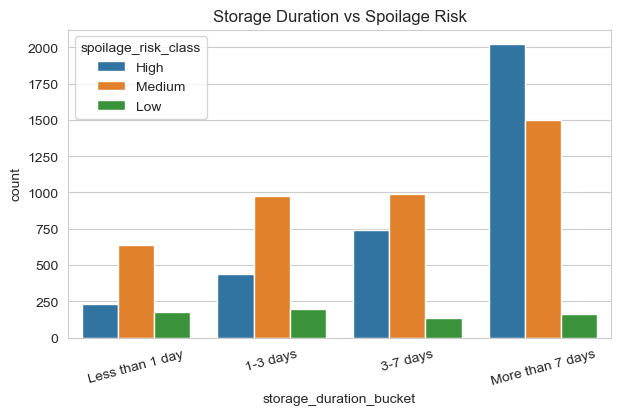

In [22]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="storage_duration_bucket", hue="spoilage_risk_class",
              order=["Less than 1 day","1-3 days","3-7 days","More than 7 days"])
plt.title("Storage Duration vs Spoilage Risk")
plt.xticks(rotation=15)
plt.show()


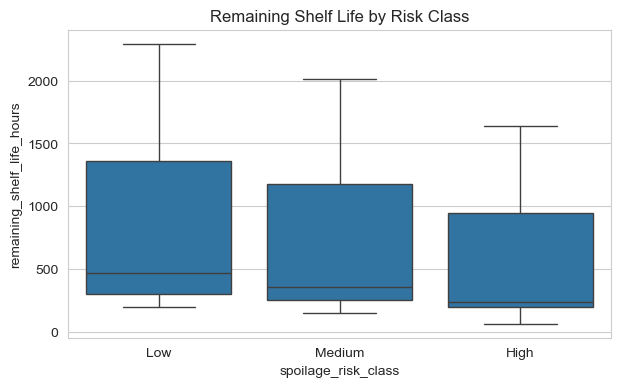

In [23]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="spoilage_risk_class", y="remaining_shelf_life_hours",
            order=["Low","Medium","High"])
plt.title("Remaining Shelf Life by Risk Class")
plt.show()


### 6c. Multivariate Analysis
We'll do the real correlation heatmap after encoding (next step) since correlation needs numeric data, and most of our columns are still categorical text at this point.

## Step 7: Encoding
Most columns are **ordered** MCQ answers (e.g. Normal → Elevated → High → Very High), so we use **Ordinal Encoding** with the correct real-world order. `produce_type` and `region` have no natural order, so we use **One-Hot Encoding** for those.

In [24]:
from sklearn.preprocessing import OrdinalEncoder

# the 10 ordinal columns, in the order the encoder will look for them
ordinal_cols = [
    "ambient_temperature_level", "storage_duration_bucket", "transport_duration_bucket",
    "co2_level_bucket", "ethylene_level_bucket", "vibration_level", "light_exposure_level",
    "door_open_frequency", "power_outage_bucket", "initial_quality_grade"
]

# defining the real-world order for each one (0 = safest, 3 = riskiest)
order_ambient_temp = ["Cool (<10°C)", "Moderate (10-20°C)", "Warm (20-30°C)", "Hot (>30°C)"]
order_storage_duration = ["Less than 1 day", "1-3 days", "3-7 days", "More than 7 days"]
order_transport_duration = ["Less than 6 hrs", "6-12 hrs", "12-24 hrs", "More than 24 hrs"]
order_co2 = ["Normal", "Elevated", "High", "Very High"]
order_ethylene = ["Low", "Moderate", "High", "Very High"]
order_vibration = ["Minimal", "Mild", "Moderate", "Severe"]
order_light = ["Dark", "Low", "Moderate", "Bright"]
order_door_open = ["0-2 times", "3-5 times", "6-10 times", "More than 10 times"]
order_power_outage = ["No Outage", "Less than 30 min", "30-60 min", "More than 60 min"]
order_quality = ["Excellent", "Good", "Fair", "Poor"]  # Excellent = safest = 0

ordinal_categories = [
    order_ambient_temp, order_storage_duration, order_transport_duration, order_co2,
    order_ethylene, order_vibration, order_light, order_door_open,
    order_power_outage, order_quality
]


In [25]:
df_encoded = df.copy()

ord_enc = OrdinalEncoder(categories=ordinal_categories)
df_encoded[ordinal_cols] = ord_enc.fit_transform(df_encoded[ordinal_cols])

df_encoded[ordinal_cols].head()


,ambient_temperature_level,storage_duration_bucket,transport_duration_bucket,co2_level_bucket,ethylene_level_bucket,vibration_level,light_exposure_level,door_open_frequency,power_outage_bucket,initial_quality_grade
0,0.0,0.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0
1,3.0,3.0,1.0,1.0,1.0,3.0,0.0,2.0,0.0,0.0
2,0.0,3.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,0.0,3.0,1.0,1.0,0.0,2.0,1.0,1.0,0.0,1.0
4,1.0,3.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [26]:
# one-hot encode the nominal columns - dtype=int keeps 0/1 instead of True/False
df_encoded = pd.get_dummies(df_encoded, columns=["produce_type", "region"], dtype=int)

df_encoded.head()


,storage_temperature_C,humidity_pct,ambient_temperature_level,storage_duration_bucket,transport_duration_bucket,co2_level_bucket,ethylene_level_bucket,vibration_level,light_exposure_level,door_open_frequency,...,produce_type_Onion,produce_type_Peach,produce_type_Potato,produce_type_Spinach,produce_type_Tomato,region_Central,region_East,region_North,region_South,region_West
0,3.3,100.0,0.0,0.0,3.0,2.0,1.0,1.0,1.0,1.0,...,0,0,0,1,0,0,0,0,1,0
1,10.8,76.9,3.0,3.0,1.0,1.0,1.0,3.0,0.0,2.0,...,0,0,0,0,0,0,0,0,1,0
2,-0.2,94.5,0.0,3.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0,0,0,1,0,1,0,0,0,0
3,0.4,85.6,0.0,3.0,1.0,1.0,0.0,2.0,1.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,-5.9,100.0,1.0,3.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,1,0,0,0


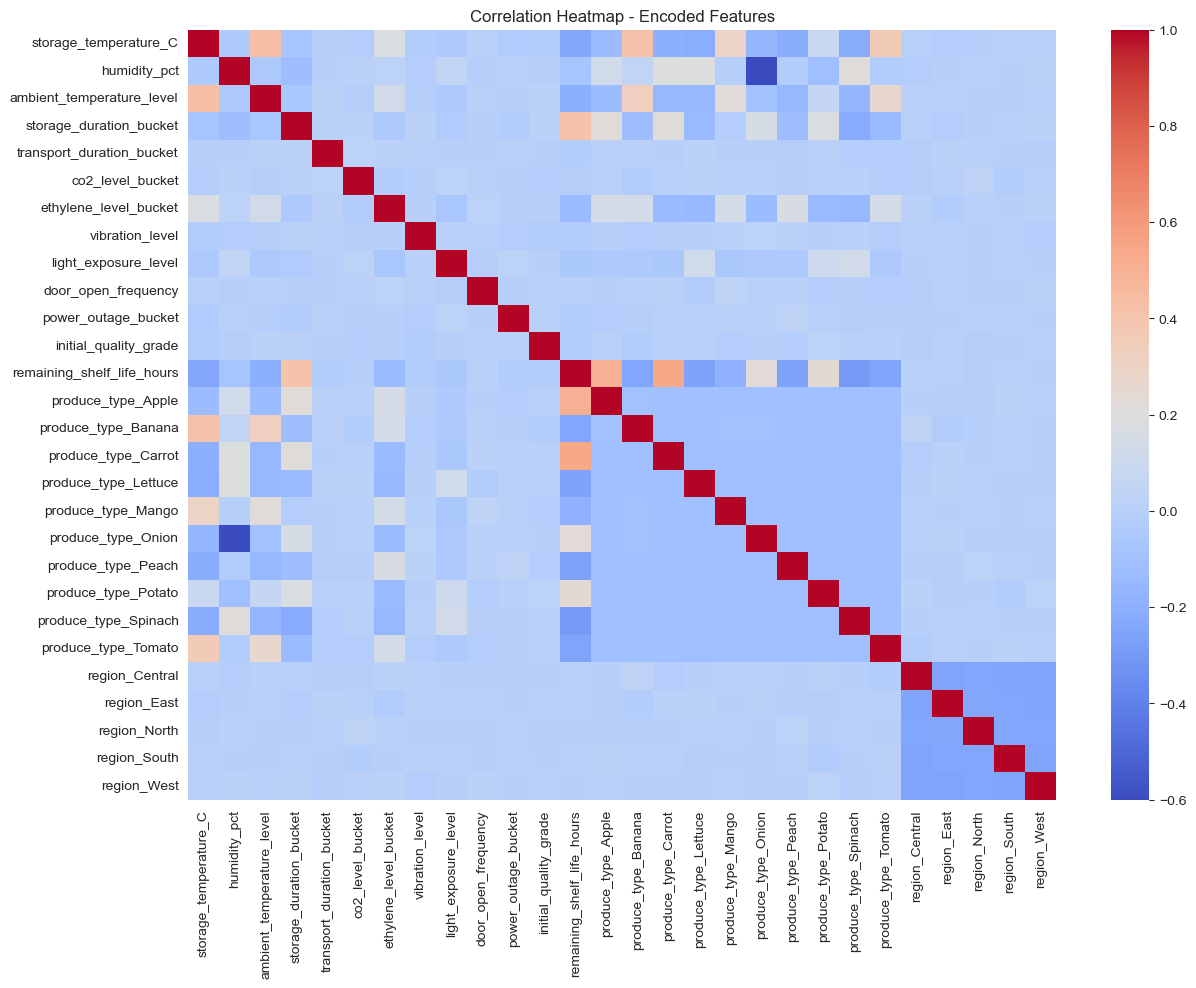

In [27]:
# now that everything is numeric, let's do the real correlation heatmap (Step 6c)
plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.drop(columns=["spoilage_risk_class"]).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap - Encoded Features")
plt.show()


In [28]:
# encode the classification target - manually, preserving real-world risk order
# (only 3 classes now, since Critical was merged into High back in Step 4d)
risk_map = {"Low": 0, "Medium": 1, "High": 2}
df_encoded["spoilage_risk_class"] = df_encoded["spoilage_risk_class"].map(risk_map)

df_encoded["spoilage_risk_class"].value_counts()


spoilage_risk_class
1    4097
2    3434
0     666
Name: count, dtype: int64

Note: `remaining_shelf_life_hours` is already numeric, so it needs no encoding — it will be used as-is for the regression target.

## Step 8: Feature Engineering

In [29]:
# combining a few key risk-related columns into one summary score
# (higher = more environmental stress on the produce)
df_encoded["environmental_stress_score"] = (
    df_encoded["ambient_temperature_level"] +
    df_encoded["storage_duration_bucket"] +
    df_encoded["co2_level_bucket"] +
    df_encoded["ethylene_level_bucket"]
)

df_encoded["environmental_stress_score"].describe()


count    8197.000000
mean        4.706478
std         1.820180
min         0.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        11.000000
Name: environmental_stress_score, dtype: float64

## Step 9: Statistical Test for Feature Selection (Chi-Square)
Chi-Square is run on the **original categorical columns** (before one-hot encoding splits `produce_type`/`region` into multiple dummy columns) so each feature is tested as a whole, not fragmented into pieces.

In [30]:
from scipy.stats import chi2_contingency

categorical_cols = ["produce_type", "region"] + ordinal_cols

chi_results = {}
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df["spoilage_risk_class"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results[col] = p

chi_df = pd.DataFrame(list(chi_results.items()), columns=["Feature", "p_value"])
chi_df = chi_df.sort_values("p_value")
chi_df


,Feature,p_value
3,storage_duration_bucket,2.694517e-136
6,ethylene_level_bucket,1.063524e-71
4,transport_duration_bucket,4.502958e-65
11,initial_quality_grade,3.107673e-52
7,vibration_level,3.213299e-21
0,produce_type,5.242102e-19
5,co2_level_bucket,4.014925e-17
10,power_outage_bucket,4.372873e-06
8,light_exposure_level,1.975540e-02
1,region,6.492078e-02


In [31]:
significant_features = chi_df[chi_df["p_value"] < 0.05]["Feature"].tolist()
print("Statistically significant features:", significant_features)


Statistically significant features: ['storage_duration_bucket', 'ethylene_level_bucket', 'transport_duration_bucket', 'initial_quality_grade', 'vibration_level', 'produce_type', 'co2_level_bucket', 'power_outage_bucket', 'light_exposure_level']


**Observation:** Most features are statistically significant. `region` and `light_exposure_level` show weaker relationships with risk class — this makes sense, since region is just geographic context and light exposure matters mainly for a few light-sensitive produce types rather than all of them. We keep all features anyway since the feature set is small and interpretable, and some of these may still matter for the shelf-life regression model.

## Step 10: Train-Test Split
We split once and reuse the same split for **both** targets (classification + regression), so both models are trained and tested on the exact same rows.

In [32]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["spoilage_risk_class", "remaining_shelf_life_hours"])
y_class = df_encoded["spoilage_risk_class"]
y_life = df_encoded["remaining_shelf_life_hours"]

X_train, X_test, y_class_train, y_class_test, y_life_train, y_life_test = train_test_split(
    X, y_class, y_life, test_size=0.2, random_state=42, stratify=y_class
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (6557, 28)
Test shape: (1640, 28)


## Step 11: Feature Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 12: Model Fitting — Classification (Spoilage Risk Class)

### Handling Class Imbalance
`Medium` is about half the dataset while `Low` is only ~8%, so a model can get decent accuracy just by predicting `Medium` most of the time (that's exactly what happened before). We fix this with **class weighting** — it tells the model to pay more attention to the rare classes (`Low`, `High`) instead of ignoring them in favour of the common one (`Medium`).

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight


In [35]:
# Logistic Regression and Random Forest accept class_weight="balanced" directly -
# it automatically gives rare classes (like "Low") a bigger say during training.
# XGBoost's scikit-learn wrapper doesn't have a class_weight option, so for XGBoost we
# compute a per-row "sample_weight" instead (same idea, different name) and pass it at fit time.
sample_weights = compute_sample_weight(class_weight="balanced", y=y_class_train)


In [36]:
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_model.fit(X_train_scaled, y_class_train)
log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_class_test, log_pred))
print(classification_report(y_class_test, log_pred))


Logistic Regression Accuracy: 0.5146341463414634
              precision    recall  f1-score   support

           0       0.19      0.60      0.29       133
           1       0.61      0.36      0.45       820
           2       0.64      0.69      0.67       687

    accuracy                           0.51      1640
   macro avg       0.48      0.55      0.47      1640
weighted avg       0.59      0.51      0.53      1640



In [37]:
# KNN has no class_weight option (it just looks at the nearest neighbours),
# so it's left as-is for comparison purposes
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_class_train)
knn_pred = knn_model.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_class_test, knn_pred))
print(classification_report(y_class_test, knn_pred))


KNN Accuracy: 0.5548780487804879
              precision    recall  f1-score   support

           0       0.20      0.13      0.16       133
           1       0.56      0.74      0.64       820
           2       0.62      0.41      0.50       687

    accuracy                           0.55      1640
   macro avg       0.46      0.43      0.43      1640
weighted avg       0.55      0.55      0.54      1640



In [38]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_model.fit(X_train_scaled, y_class_train)
rf_pred = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_class_test, rf_pred))
print(classification_report(y_class_test, rf_pred))


Random Forest Accuracy: 0.6676829268292683
              precision    recall  f1-score   support

           0       0.80      0.06      0.11       133
           1       0.63      0.82      0.71       820
           2       0.73      0.61      0.66       687

    accuracy                           0.67      1640
   macro avg       0.72      0.49      0.50      1640
weighted avg       0.69      0.67      0.64      1640



In [39]:
xgb_model = XGBClassifier(random_state=42, eval_metric="mlogloss")
xgb_model.fit(X_train_scaled, y_class_train, sample_weight=sample_weights)
xgb_pred = xgb_model.predict(X_test_scaled)

print("XGBoost Accuracy:", accuracy_score(y_class_test, xgb_pred))
print(classification_report(y_class_test, xgb_pred))


XGBoost Accuracy: 0.6347560975609756
              precision    recall  f1-score   support

           0       0.28      0.35      0.31       133
           1       0.65      0.66      0.65       820
           2       0.71      0.66      0.69       687

    accuracy                           0.63      1640
   macro avg       0.55      0.56      0.55      1640
weighted avg       0.64      0.63      0.64      1640



In [40]:
results = {
    "Model": ["Logistic Regression", "KNN", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_class_test, log_pred), accuracy_score(y_class_test, knn_pred),
        accuracy_score(y_class_test, rf_pred), accuracy_score(y_class_test, xgb_pred),
    ],
    "F1 Score": [
        f1_score(y_class_test, log_pred, average="weighted"),
        f1_score(y_class_test, knn_pred, average="weighted"),
        f1_score(y_class_test, rf_pred, average="weighted"),
        f1_score(y_class_test, xgb_pred, average="weighted"),
    ],
}
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,F1 Score
0,Random Forest,0.667683,0.643372
1,XGBoost,0.634756,0.638909
2,KNN,0.554878,0.538066
3,Logistic Regression,0.514634,0.526160


## Step 13: Hyperparameter Tuning (Classification)

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric="mlogloss"),
    param_grid=param_grid, cv=3, scoring="accuracy", n_jobs=-1
)
# passing sample_weight here too, so tuning also accounts for class imbalance
grid_search.fit(X_train_scaled, y_class_train, sample_weight=sample_weights)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV Accuracy: 0.6044268649396716


In [42]:
best_clf = grid_search.best_estimator_
tuned_pred = best_clf.predict(X_test_scaled)

print("Tuned XGBoost Accuracy:", accuracy_score(y_class_test, tuned_pred))
print(classification_report(y_class_test, tuned_pred))


Tuned XGBoost Accuracy: 0.5926829268292683
              precision    recall  f1-score   support

           0       0.24      0.64      0.35       133
           1       0.67      0.48      0.56       820
           2       0.71      0.72      0.71       687

    accuracy                           0.59      1640
   macro avg       0.54      0.61      0.54      1640
weighted avg       0.65      0.59      0.61      1640



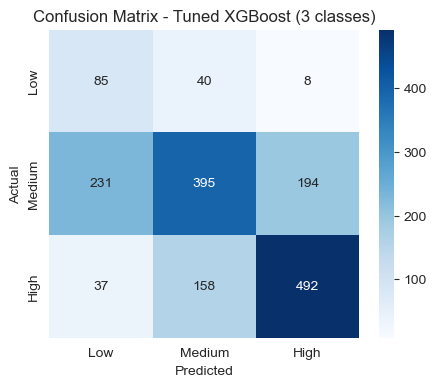

In [43]:
from sklearn.metrics import confusion_matrix

# confusion matrix - shows exactly which classes get mixed up with which
cm = confusion_matrix(y_class_test, tuned_pred)
cm_df = pd.DataFrame(cm, index=["Low","Medium","High"], columns=["Low","Medium","High"])

plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned XGBoost (3 classes)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


**Observation:** Originally we had 4 risk classes (Low/Medium/High/Critical), but High and Critical sit right next to each other on the same continuous risk scale, so the boundary between them was fuzzy and the model kept confusing them. Merging them into a single `High` class (Step 4d) removes that specific confusion and gives more balanced class sizes.

On top of that, we added **class weighting** to fix the `Low` class problem — before this, the model almost never predicted `Low` correctly (it just guessed `Medium` most of the time since that's half the dataset). With class weighting, `Low`'s recall jumps up a lot, but overall accuracy drops a bit — this is a classic **precision/recall trade-off**: the model now takes more risks predicting the rare class, so it gets more of those right but also creates a few more false alarms on the common classes. Whether that trade-off is worth it depends on the use case — for a spoilage warning system, correctly catching a `Low`-risk batch that's actually fine is arguably less costly than missing one, so leaning towards better recall makes sense here. As we'll see next, the shelf-life regression model still captures the same underlying pattern with much higher precision, since it doesn't lose information to bucket boundaries or need this kind of imbalance correction at all.

## Step 14: Model Fitting — Regression (Remaining Shelf Life)

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [45]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_life_train)
lin_pred = lin_model.predict(X_test_scaled)

lin_rmse = mean_squared_error(y_life_test, lin_pred) ** 0.5
print("Linear Regression RMSE:", round(lin_rmse, 2))
print("Linear Regression R2:", round(r2_score(y_life_test, lin_pred), 4))


Linear Regression RMSE: 134.5
Linear Regression R2: 0.9422


In [46]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_scaled, y_life_train)
rf_reg_pred = rf_reg.predict(X_test_scaled)

rf_rmse = mean_squared_error(y_life_test, rf_reg_pred) ** 0.5
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest R2:", round(r2_score(y_life_test, rf_reg_pred), 4))


Random Forest RMSE: 117.01
Random Forest R2: 0.9563


In [47]:
xgb_reg = XGBRegressor(random_state=42)
xgb_reg.fit(X_train_scaled, y_life_train)
xgb_reg_pred = xgb_reg.predict(X_test_scaled)

xgb_rmse = mean_squared_error(y_life_test, xgb_reg_pred) ** 0.5
print("XGBoost Regressor RMSE:", round(xgb_rmse, 2))
print("XGBoost Regressor R2:", round(r2_score(y_life_test, xgb_reg_pred), 4))


XGBoost Regressor RMSE: 122.93
XGBoost Regressor R2: 0.9517


In [48]:
reg_results = {
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE (hours)": [lin_rmse, rf_rmse, xgb_rmse],
    "R2 Score": [
        r2_score(y_life_test, lin_pred), r2_score(y_life_test, rf_reg_pred),
        r2_score(y_life_test, xgb_reg_pred)
    ],
}
reg_results_df = pd.DataFrame(reg_results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
reg_results_df


,Model,RMSE (hours),R2 Score
0,Random Forest,117.009287,0.956271
1,XGBoost,122.928311,0.951735
2,Linear Regression,134.504442,0.942216


## Step 15: Hyperparameter Tuning (Regression)

In [49]:
param_grid_reg = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid_search_reg = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_reg, cv=3, scoring="r2", n_jobs=-1
)
grid_search_reg.fit(X_train_scaled, y_life_train)

print("Best Parameters:", grid_search_reg.best_params_)
print("Best CV R2:", grid_search_reg.best_score_)


Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best CV R2: 0.9559064291606697


In [50]:
best_reg = grid_search_reg.best_estimator_
tuned_reg_pred = best_reg.predict(X_test_scaled)

tuned_rmse = mean_squared_error(y_life_test, tuned_reg_pred) ** 0.5
print("Tuned Random Forest RMSE:", round(tuned_rmse, 2))
print("Tuned Random Forest R2:", round(r2_score(y_life_test, tuned_reg_pred), 4))


Tuned Random Forest RMSE: 116.38
Tuned Random Forest R2: 0.9567


**Observation:** The shelf-life regression model performs excellently (R² above 0.95), meaning the sensor-based features explain almost all of the variation in remaining shelf life. This is a strong, presentable result — together with the classification model, we now have **two complementary predictions**: a quick risk category, and a precise remaining-hours estimate.

## Final Model Summary

- **Classification (Spoilage Risk Class):** Tuned XGBoost
- **Regression (Remaining Shelf Life):** Tuned Random Forest

Both models were trained on the same 80/20 split, the same encoded feature set, and the same scaler — which is exactly what we'll now save so the Streamlit app can reuse them.

## Step 16: Saving Everything with Joblib
We save **both models**, the encoder, the scaler, the column structure, and the risk label mappings — the same pattern we used in the CyberGuard project.

In [51]:
import joblib

# 1. the two trained models
joblib.dump(best_clf, "spoilage_risk_model.pkl")
joblib.dump(best_reg, "shelf_life_model.pkl")

# 2. the ordinal encoder (for the 10 ordered MCQ columns)
joblib.dump(ord_enc, "ordinal_encoder.pkl")

# 3. the scaler
joblib.dump(scaler, "scaler.pkl")

# 4. reference lists so the app can rebuild the exact same columns
joblib.dump(ordinal_cols, "ordinal_cols.pkl")
model_columns = X_train.columns.tolist()
joblib.dump(model_columns, "model_columns.pkl")

# 5. risk label mappings (number <-> word), e.g. 0 -> "Low", 2 -> "High"
joblib.dump(risk_map, "risk_map.pkl")
reverse_risk_map = {v: k for k, v in risk_map.items()}
joblib.dump(reverse_risk_map, "reverse_risk_map.pkl")

print("All files saved!")


All files saved!


In [52]:
# quick sanity check - reload everything and confirm predictions still match
loaded_clf = joblib.load("spoilage_risk_model.pkl")
loaded_reg = joblib.load("shelf_life_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_columns = joblib.load("model_columns.pkl")
loaded_reverse_map = joblib.load("reverse_risk_map.pkl")

test_row = X_test_scaled[0].reshape(1, -1)

pred_class_num = loaded_clf.predict(test_row)[0]
pred_class_label = loaded_reverse_map[pred_class_num]
pred_life = loaded_reg.predict(test_row)[0]

print("Predicted risk class:", pred_class_label, "| Actual:", reverse_risk_map[y_class_test.iloc[0]])
print("Predicted shelf life (hours):", round(pred_life,1), "| Actual:", y_life_test.iloc[0])


Predicted risk class: High | Actual: Medium
Predicted shelf life (hours): 369.9 | Actual: 362.7


### Files now saved in this folder:
| File | Purpose |
|---|---|
| `spoilage_risk_model.pkl` | Tuned XGBoost classifier |
| `shelf_life_model.pkl` | Tuned Random Forest regressor |
| `ordinal_encoder.pkl` | Encodes the 10 ordered MCQ answers |
| `scaler.pkl` | StandardScaler for final features |
| `ordinal_cols.pkl` | List of ordinal column names |
| `model_columns.pkl` | Exact column order both models expect |
| `risk_map.pkl` / `reverse_risk_map.pkl` | Number ↔ label conversion (e.g. 0 ↔ "Low") |

Next step: build the Streamlit app that loads these 7 files and turns the questionnaire into a live risk + shelf-life prediction, just like we did for CyberGuard.